In [1]:
import pandas as pd
import matplotlib.pyplot as plt

master = pd.read_csv("../data/cleaned/master_dataset.csv")

Matplotlib is building the font cache; this may take a moment.


In [4]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp",
    "shipping_limit_date"
]

for col in date_columns:
    if col in master.columns:
        master[col] = pd.to_datetime(
            master[col],
            format="mixed",
            errors="coerce"
        )

In [5]:
master.shape


(165649, 42)

In [6]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165649 entries, 0 to 165648
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       165649 non-null  object        
 1   customer_id                    165649 non-null  object        
 2   order_status                   165649 non-null  object        
 3   order_purchase_timestamp       165649 non-null  datetime64[ns]
 4   order_approved_at              165470 non-null  datetime64[ns]
 5   order_delivered_carrier_date   162883 non-null  datetime64[ns]
 6   order_delivered_customer_date  161330 non-null  datetime64[ns]
 7   order_estimated_delivery_date  165649 non-null  datetime64[ns]
 8   customer_unique_id             165649 non-null  object        
 9   customer_zip_code_prefix       165649 non-null  int64         
 10  customer_city                  165649 non-null  object        
 11  

In [7]:
master.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_item_id_y,price_y,freight_value_y
count,165649,165470,162883,161330,165649,165649.000000,165640.000000,165640.000000,165640.000000,163704.000000,...,162528.000000,162528.000000,162528.000000,164792.000000,164792.000000,164792.000000,164792.000000,164816.000000,164816.000000,164816.00000
mean,2017-12-30 10:01:20.270167808,2017-12-30 21:23:10.373100544,2018-01-04 04:23:31.115690496,2018-01-13 09:19:53.122742272,2018-01-23 09:25:54.648684800,35022.556140,1.092460,3.146764,243.474419,3.843822,...,48.529466,776.308556,2.111378,2096.402477,30.369150,17.016020,22.977214,1.638967,109.617043,19.58478
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1003.000000,1.000000,0.000000,0.000000,1.000000,...,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,0.850000,0.00000
25%,2017-09-13 15:20:19,2017-09-14 02:43:53.249999872,2017-09-19 13:32:36,2017-09-27 15:15:16,2017-10-04 00:00:00,11035.000000,1.000000,1.000000,71.817500,3.000000,...,42.000000,341.000000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,36.750000,12.73000
50%,2018-01-18 12:24:35,2018-01-18 16:57:42.500000,2018-01-24 10:33:15,2018-02-02 00:44:58,2018-02-14 00:00:00,23909.000000,1.000000,2.000000,135.400000,5.000000,...,51.000000,590.000000,1.000000,700.000000,25.000000,13.000000,20.000000,1.000000,69.000000,16.11000
75%,2018-05-02 21:25:27,2018-05-03 04:15:16,2018-05-07 13:30:30,2018-05-14 18:28:46,2018-05-24 00:00:00,59300.000000,1.000000,4.000000,246.920000,5.000000,...,57.000000,973.000000,3.000000,1750.000000,38.000000,21.000000,30.000000,2.000000,122.612500,21.04000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,99990.000000,29.000000,24.000000,13664.080000,5.000000,...,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,21.000000,6735.000000,409.68000
std,NaN,NaN,NaN,NaN,NaN,30112.543039,0.746138,2.994186,442.622643,1.509799,...,10.084278,651.502721,1.649351,3757.991000,16.256476,13.781256,11.706425,1.600551,168.221924,15.90051


In [8]:
master.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   179
order_delivered_carrier_date       2766
order_delivered_customer_date      4319
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
payment_sequential                    9
payment_type                          9
payment_installments                  9
payment_value                         9
review_id                          1945
review_score                       1945
review_comment_title             145266
review_comment_message            91788
review_creation_date               1945
review_answer_timestamp            1945
order_item_id_x                     833
product_id_x                        833
seller_id_x                         833


In [9]:
master["purchase_year"] = master["order_purchase_timestamp"].dt.year
master["purchase_month"] = master["order_purchase_timestamp"].dt.month_name()
master["purchase_day"] = master["order_purchase_timestamp"].dt.day_name()
master["purchase_hour"] = master["order_purchase_timestamp"].dt.hour

In [10]:
master["order_status"].value_counts()

order_status
delivered      161329
shipped          1474
canceled         1076
unavailable       654
processing        572
invoiced          534
created             5
approved            5
Name: count, dtype: int64

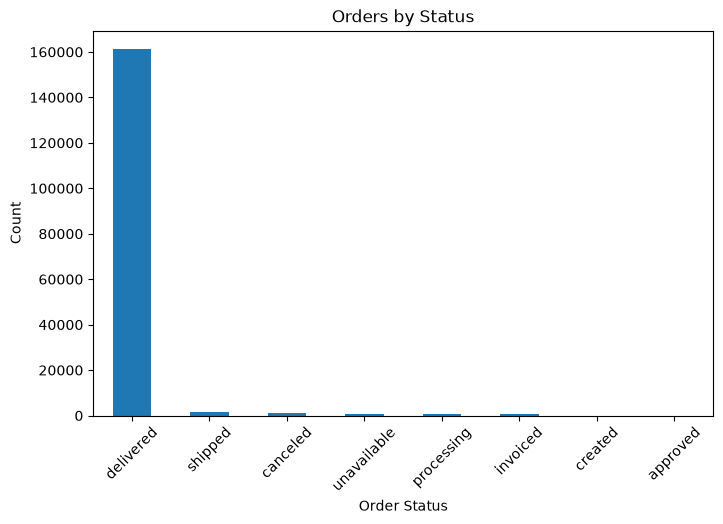

In [11]:
master["order_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [12]:
master["payment_type"].value_counts()

payment_type
credit_card    120466
boleto          34806
voucher          8133
debit_card       2232
not_defined         3
Name: count, dtype: int64

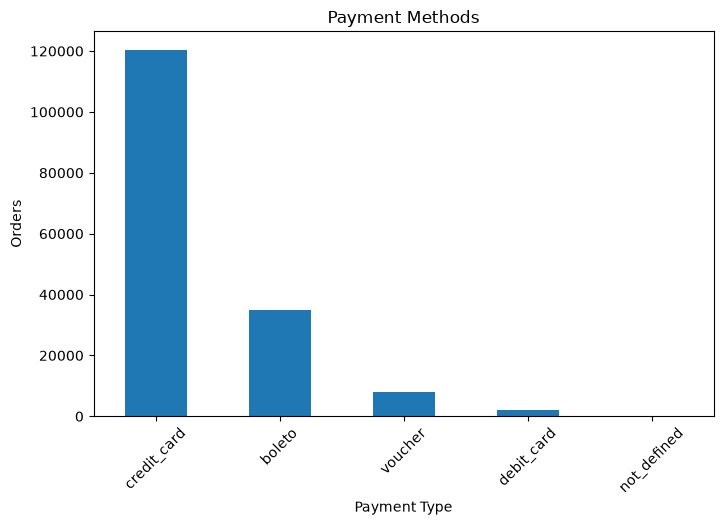

In [13]:
master["payment_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Methods")
plt.xlabel("Payment Type")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

In [14]:
master["review_score"].value_counts().sort_index()

review_score
1.0    27876
2.0     6634
3.0    14202
4.0    29461
5.0    85531
Name: count, dtype: int64

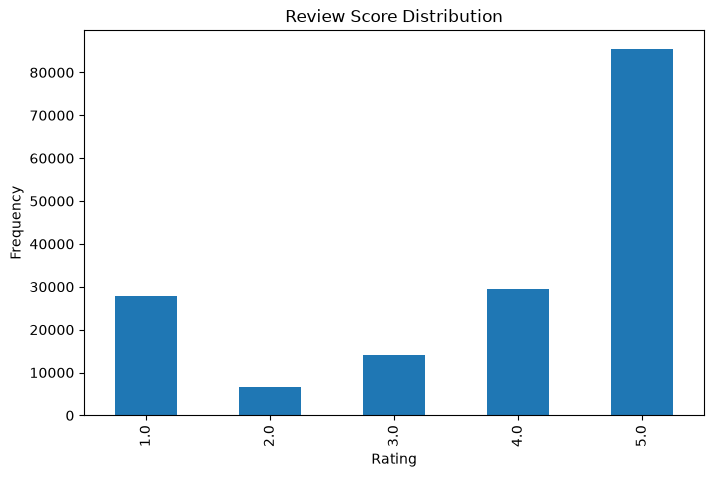

In [15]:
master["review_score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Review Score Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [16]:
top_products = (
    master["product_category_name"]
    .value_counts()
    .head(10)
)

top_products

product_category_name
cama_mesa_banho           17616
moveis_decoracao          15573
beleza_saude              12943
informatica_acessorios    12396
utilidades_domesticas     11710
esporte_lazer             11682
ferramentas_jardim         7712
relogios_presentes         7431
telefonia                  5971
automotivo                 5743
Name: count, dtype: int64

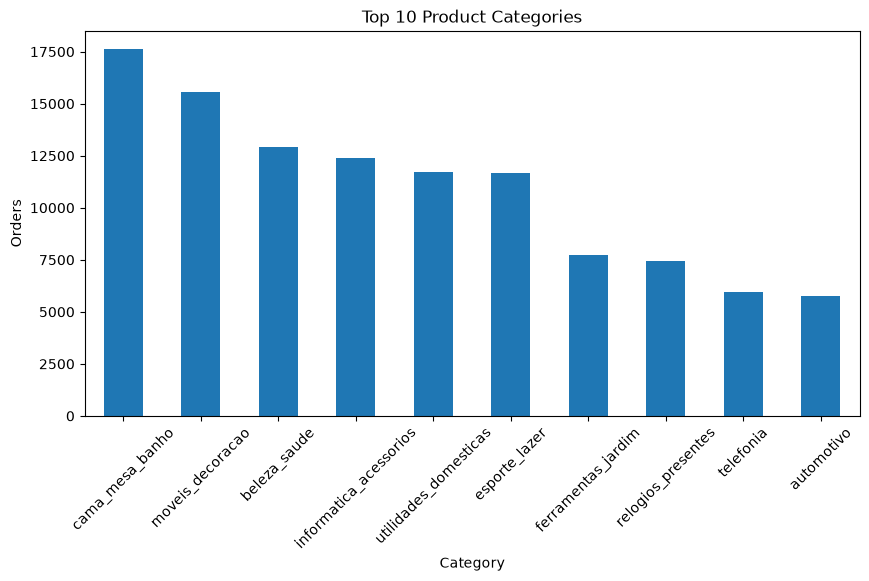

In [17]:
top_products.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

In [18]:
top_states = master["customer_state"].value_counts().head(10)

top_states

customer_state
SP    71045
RJ    21100
MG    18775
RS     9281
PR     8611
SC     6199
BA     5503
GO     4080
DF     3370
ES     3032
Name: count, dtype: int64

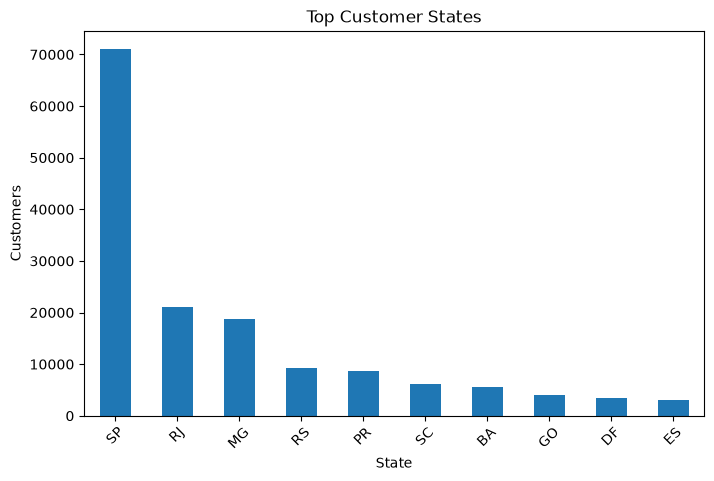

In [19]:
top_states.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top Customer States")
plt.xlabel("State")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.show()

In [20]:
monthly_orders = (
    master.groupby("purchase_month")
    .size()
)

C:\Users\ankur\AppData\Local\Temp\ipykernel_15872\3544741167.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_orders = master.groupby("purchase_month").size()


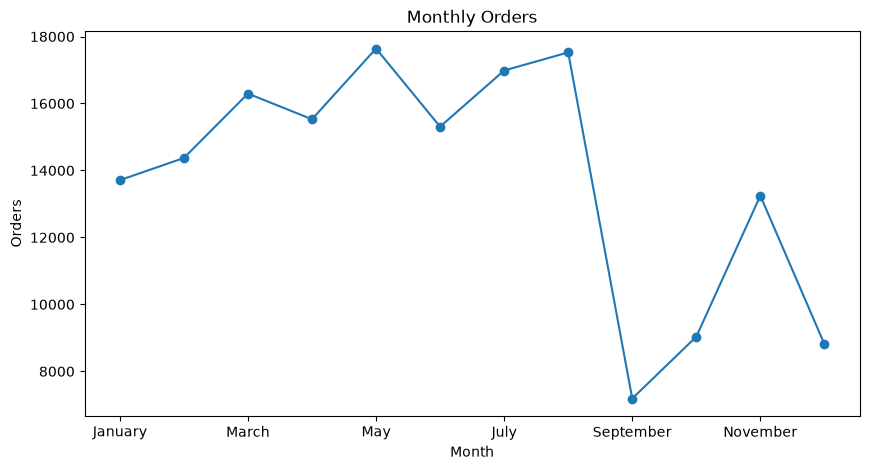

In [21]:
months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

master["purchase_month"] = pd.Categorical(
    master["purchase_month"],
    categories=months,
    ordered=True
)

monthly_orders = master.groupby("purchase_month").size()

monthly_orders.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

In [22]:
master["payment_value"].describe()

count    165640.000000
mean        243.474419
std         442.622643
min           0.000000
25%          71.817500
50%         135.400000
75%         246.920000
max       13664.080000
Name: payment_value, dtype: float64

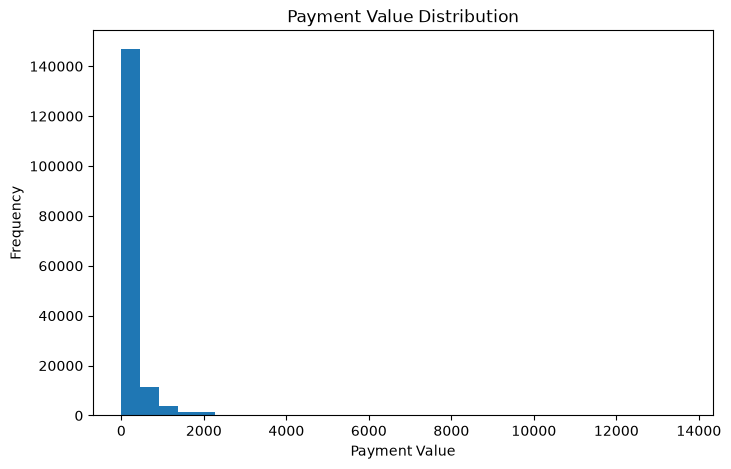

In [23]:
master["payment_value"].plot(
    kind="hist",
    bins=30,
    figsize=(8,5)
)

plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.show()

In [24]:
master["delivery_days"] = (
    master["order_delivered_customer_date"] -
    master["order_purchase_timestamp"]
).dt.days

In [25]:
master["delivery_days"].describe()

count    161330.000000
mean         11.865332
std           9.162612
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

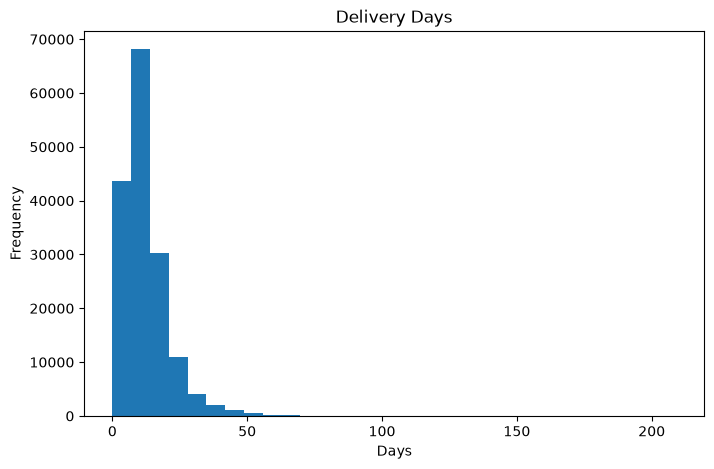

In [26]:
master["delivery_days"].plot(
    kind="hist",
    bins=30,
    figsize=(8,5)
)

plt.title("Delivery Days")
plt.xlabel("Days")
plt.show()